In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa
import seaborn as sns
import plot_network_maps
from _helpers import mock_snakemake
from cartopy import crs as ccrs
import time
# from plot_network_maps import plot_demand_map, plot_capacity_map, plot_base_capacity_map

In [2]:
input_network = "../resources/SoCal/western/elec_s_call_ec_lv1.0_REM-3h_E.nc"
n = pypsa.Network(input_network)
# Plot demand_map

INFO:pypsa.io:Imported network elec_s_call_ec_lv1.0_REM-3h_E.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units


In [3]:
n.loads_t['p_set'].columns

Index(['36595 AC', '36601 AC', '36602 AC', '36607 AC', '36608 AC', '36609 AC',
       '36610 AC', '36611 AC', '36612 AC', '36613 AC',
       ...
       '37719 AC', '37722 AC', '37723 AC', '37724 AC', '37732 AC', '37733 AC',
       '37734 AC', '37737 AC', '37738 AC', '37753 AC'],
      dtype='object', name='Load', length=921)

In [4]:
start_time = time.time()
n.pf(snapshots=n.snapshots[:1])
print("Power flow calculation took %s seconds ---" % (time.time() - start_time))

INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots MultiIndex([(2030, '2030-01-01 00:00:00')],
           name='snapshot')
INFO:pypsa.pf:Newton-Raphson solved in 100 iterations with error of 3405477716057781772074318949404820651160962172559422484567095999372101720544907047277361026398236526126294668391606736912384.000000 in 5.931549 seconds
INFO:pypsa.pf:Balancing power on single-bus sub-network SubNetwork 1 for snapshots MultiIndex([(2030, '2030-01-01 00:00:00')],
           name='snapshot')
INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 2 for snapshots MultiIndex([(2030, '2030-01-01 00:00:00')],
           name='snapshot')
INFO:pypsa.pf:Newton-Raphson solved in 2 iterations with error of 0.000000 in 0.016539 seconds
INFO:pypsa.pf:Balancing power on single-bus sub-network SubNetwork 3 for snapshots MultiIndex([(2030, '2030-01-01 00:00:00')],
           name='snapshot')
INFO:pypsa.pf:Balancing power on single-bus sub-n

Power flow calculation took 62.92702507972717 seconds ---


In [5]:
n.buses.shape

(1096, 24)

In [9]:
for i, row in n.sub_networks.iterrows():
    print(i, row.obj.buses().shape)

0 (1088, 24)
1 (1, 24)
2 (5, 24)
3 (1, 24)
4 (1, 24)


In [32]:
sub_n = n.sub_networks.obj.iloc[0]
subnet = pypsa.Network()
subnet.set_snapshots(n.snapshots)
subnet.name="SoCal_subnet"
subnet.import_components_from_dataframe(sub_n.buses(),'Bus')
for comp in n.components:
    df = getattr(n, comp.lower() + "s", None)
    if df is None:
        print(f"Component {comp}s not found in network.")
        continue
    if "bus" in df.columns:  # single-bus components (e.g., Load, Generator)
        df_sub = df[df["bus"].isin(sub_n.buses())]
    elif {"bus0", "bus1"} <= set(df.columns):  # branches (e.g., Line, Link, Transformer)
        df_sub = df[df["bus0"].isin(sub_n.buses()) & df["bus1"].isin(sub_n.buses())]
    else:
        df_sub = df.copy()  # skip if not connected
        df_sub = df_sub.iloc[0:0]

    if not df_sub.empty:
        subnet.import_components_from_dataframe(df_sub, comp)

Component Networks not found in network.
Component SubNetworks not found in network.
Component Buss not found in network.
Component GlobalConstraints not found in network.
Component LineTypes not found in network.
Component TransformerTypes not found in network.
Component StorageUnits not found in network.
Component ShuntImpedances not found in network.


In [11]:
regions_onshore = "../resources/SoCal/western/Geospatial/regions_onshore_s_all.geojson"
snakemake = mock_snakemake(
            "plot_network_maps",
            interconnect="western",
            clusters="all",
            simpl="",
            ll="v1.0",
            opts="REM-3h",
            sector="E",
        )
onshore_regions = gpd.read_file(regions_onshore)
plot_network_maps.sanitize_carriers(n, snakemake.config)
generating_link_carrier_map = {"fuel cell": "H2", "battery discharger": "battery"}
# mappers
generating_link_carrier_map = {"fuel cell": "H2", "battery discharger": "battery"}

# carriers to plot
carriers = (
    snakemake.params.electricity["conventional_carriers"]
    + snakemake.params.electricity["renewable_carriers"]
    + snakemake.params.electricity["extendable_carriers"]["Generator"]
    + snakemake.params.electricity["extendable_carriers"]["StorageUnit"]
    + snakemake.params.electricity["extendable_carriers"]["Store"]
    + snakemake.params.electricity["extendable_carriers"]["Link"]
    + ["imports"]
)
carriers = list(set(carriers))  # remove any duplicates


Snakefile:76: DeprecationWarning:

invalid escape sequence '\.'

Snakefile:77: DeprecationWarning:

invalid escape sequence '\.'

Snakefile:322: DeprecationWarning:

invalid escape sequence '\$'

Snakefile:332: DeprecationWarning:

invalid escape sequence '\$'



In [25]:
TITLE_SIZE = 16
# Bus size in legend
bus_sizes = [5000, 10e3, 20e3]  # in MW # original
bus_sizes = np.array(bus_sizes) / 10000

/resnick/groups/enceladus/jyzhao/pypsa-usa/pypsa-usa/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



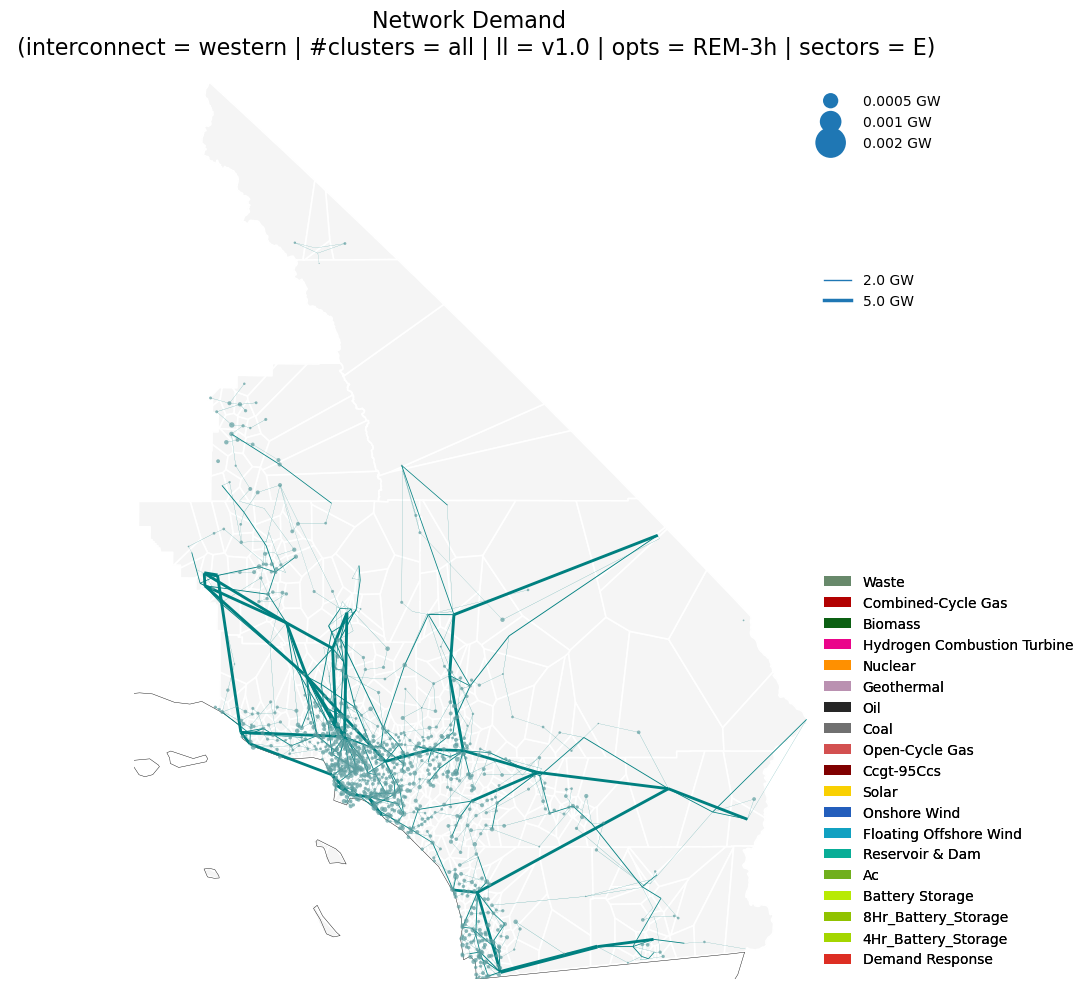

In [33]:
def plot_demand_map(
    n: pypsa.Network,
    regions: gpd.GeoDataFrame,
    carriers: list[str],
    save: str,
    **wildcards,
) -> None:
    """Plots map of network nodal demand."""
    # get data

    bus_values = plot_network_maps.get_demand_base(n).mul(1e-3)
    line_values = n.lines.s_nom
    link_values = n.links[n.links.carrier == "AC"].p_nom.replace(to_replace={pd.NA: 0})

    # plot data
    title = plot_network_maps.create_title("Network Demand", **wildcards)
    interconnect = wildcards.get("interconnect", None)
    bus_scale = plot_network_maps.get_bus_scale(interconnect) if interconnect else 1
    line_scale = plot_network_maps.get_line_scale(interconnect) if interconnect else 1

    bus_scale = bus_scale / 1000
    # line_scale = line_scale * 100

    fig, ax = plt.subplots(
        figsize=(10, 10),
        subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())},
    )

    line_width = line_values / line_scale
    link_width = link_values / line_scale

    with plt.rc_context({"patch.linewidth": 0.1}):
        n.plot(
            bus_sizes=bus_values / bus_scale,
            # bus_colors=None,
            bus_alpha=0.7,
            line_widths=line_width,
            link_widths=0 if link_width.empty else link_width,
            line_colors="teal",
            ax=ax,
            margin=0.2,
            color_geomap=None,
        )

    # onshore regions
    regions.plot(
        ax=ax,
        facecolor="whitesmoke",
        edgecolor="white",
        aspect="equal",
        transform=ccrs.PlateCarree(),
        linewidth=1.2,
    )
    ax.set_extent(regions.total_bounds[[0, 2, 1, 3]])

    legend_kwargs = {"loc": "upper left", "frameon": False}

    line_sizes = [2000, 5000]  # in MW

    plot_network_maps.add_legend_circles(
        ax,
        [s / bus_scale for s in bus_sizes],
        [f"{s / 1000} GW" for s in bus_sizes],
        legend_kw={"bbox_to_anchor": (1, 1), **legend_kwargs},
    )
    plot_network_maps.add_legend_lines(
        ax,
        [s / line_scale for s in line_sizes],
        [f"{s / 1000} GW" for s in line_sizes],
        legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
    )
    plot_network_maps.add_legend_patches(
        ax,
        n.carriers.color.fillna("#000000"),
        n.carriers.nice_name,
        legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
    )
    if not title:
        ax.set_title("Total Annual Demand (MW)", fontsize=TITLE_SIZE, pad=20)
    else:
        ax.set_title(title, fontsize=TITLE_SIZE, pad=20)
    fig.tight_layout()
    if save:
        fig.savefig(save)
        plt.close()
        return None
    else:
        return fig, ax

fig, ax = plot_demand_map(
        n,
        onshore_regions,
        carriers,
        None,
        **snakemake.wildcards,
    )

In [40]:
def plot_capacity_map(
    n: pypsa.Network,
    bus_values: pd.DataFrame,
    line_values: pd.DataFrame,
    link_values: pd.DataFrame,
    regions: gpd.GeoDataFrame,
    bus_scale=1,
    line_scale=1,
    title=None,
    flow=None,
    line_colors="teal",
    link_colors="green",
    line_cmap="viridis",
    line_norm=None,
) -> tuple[plt.figure, plt.axes]:
    """Generic network plotting function for capacity pie charts at each node."""
    fig, ax = plt.subplots(
        figsize=(10, 10),
        subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())},
    )

    line_width = line_values / line_scale
    link_width = link_values / line_scale

    with plt.rc_context({"patch.linewidth": 0.1}):
        n.plot(
            bus_sizes=bus_values / bus_scale,
            bus_colors=n.carriers.color,
            bus_alpha=0.7,
            line_widths=line_width,
            link_widths=0 if link_width.empty else link_width,
            line_colors=line_colors,
            link_colors=link_colors,
            ax=ax,
            margin=0.2,
            color_geomap=True,
            flow=flow,
            line_cmap=line_cmap,
            line_norm=line_norm,
        )

    # onshore regions
    regions.plot(
        ax=ax,
        facecolor="whitesmoke",
        edgecolor="white",
        aspect="equal",
        transform=ccrs.PlateCarree(),
        linewidth=1.2,
    )
    ax.set_extent(regions.total_bounds[[0, 2, 1, 3]])

    legend_kwargs = {"loc": "upper left", "frameon": False}
    # bus_sizes = [5000, 10e3, 50e3]  # in MW
    line_sizes = [2000, 5000]  # in MW

    plot_network_maps.add_legend_circles(
        ax,
        [s / bus_scale for s in bus_sizes],
        [f"{s / 1000} GW" for s in bus_sizes],
        legend_kw={"bbox_to_anchor": (1, 1), **legend_kwargs},
    )
    plot_network_maps.add_legend_lines(
        ax,
        [s / line_scale for s in line_sizes],
        [f"{s / 1000} GW" for s in line_sizes],
        legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
    )
    plot_network_maps.add_legend_patches(
        ax,
        n.carriers.color.fillna("#000000"),
        n.carriers.nice_name,
        legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
    )
    if not title:
        ax.set_title("Capacity (MW)", fontsize=TITLE_SIZE, pad=20)
    else:
        ax.set_title(title, fontsize=TITLE_SIZE, pad=20)
    fig.tight_layout()

    return fig, ax


def plot_base_capacity_map(
    n: pypsa.Network,
    regions: gpd.GeoDataFrame,
    carriers: list[str],
    save: str,
    **wildcards,
) -> None:
    """Plots map of base network capacities."""
    # get data

    bus_values = plot_network_maps.get_capacity_base(n)
    bus_values = bus_values[bus_values.index.get_level_values(1).isin(carriers)]
    bus_values = plot_network_maps.remove_sector_buses(bus_values).groupby(by=["bus", "carrier"]).sum()

    line_values = n.lines.s_nom
    link_values = n.links[n.links.carrier == "AC"].p_nom.replace(to_replace={pd.NA: 0})

    # plot data

    title = plot_network_maps.create_title("Base Network Capacities", **wildcards)
    interconnect = wildcards.get("interconnect", None)
    bus_scale = plot_network_maps.get_bus_scale(interconnect) if interconnect else 1
    line_scale = plot_network_maps.get_line_scale(interconnect) if interconnect else 1

    fig, ax = plot_capacity_map(
        n=n,
        bus_values=bus_values,
        line_values=line_values,
        link_values=link_values,
        regions=regions,
        line_scale=line_scale,
        bus_scale=bus_scale,
        title=title,
    )
    if save:
        fig.savefig(save)
        plt.close()
        return None
    else:
        return fig, ax

/resnick/groups/enceladus/jyzhao/pypsa-usa/pypsa-usa/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



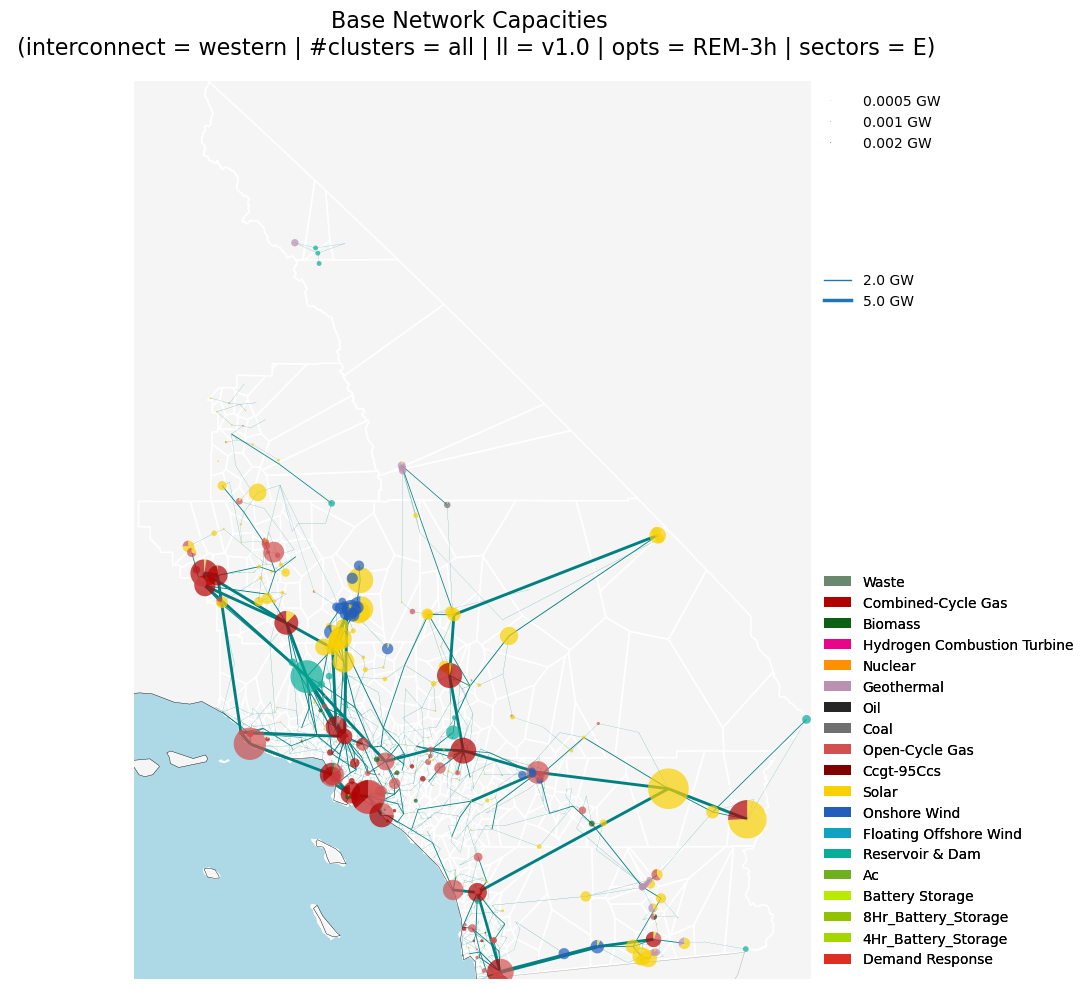

In [41]:
fig, ax = plot_base_capacity_map(
        n,
        onshore_regions,
        carriers,
        None,
        **snakemake.wildcards,
    )